In [41]:
from pathlib import Path
import yaml 
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
with open('../config.local.yaml') as f:
    configs = yaml.safe_load(f)

data_path = configs['paths']['bambi_data']

In [4]:
metadata_dir = Path(data_path) / 'flight_metadata'
metadata = sorted(metadata_dir.iterdir())

json_ex = json.loads(metadata[0].read_text())
json_ex

{'flight_key': '0',
 'split': 'train',
 'generated_at': '2026-02-07T12:04:10.731498',
 'frame_count': 107,
 'flight_info': {'sharepoint_link': 'https://fhooe.sharepoint.com/teams/BAMBI-dev/Freigegebene%20Dokumente/Processed/Spektakulair/2023_07_27_NOe_Purkersdorf/1581F5FJB22A700A0DW3_M3TE/083_Schwarzwild/',
  'key': '0',
  'weather': 1,
  'start_time': '2023-07-27T06:46:06',
  'end_time': '2023-07-27T07:13:47',
  'drone_name': 'Mavic 3 Thermal',
  'drone_instance_id': 5},
 'species_present': {'Q58697': {'species_name': 'Sus scrofa (Wild boar)',
   'wikidata_id': 'Q58697',
   'contains_occluded_frames': True,
   'contains_unoccluded_frames': False,
   'contains_unknown_sex': True,
   'contains_male': False,
   'contains_female': False,
   'contains_unknown_age': True,
   'contains_juvenile': False,
   'contains_adult': False,
   'num_labels': 2,
   'num_label_states': 107}}}

In [5]:
records = []

for file in metadata:
    try:
        text = json.loads(file.read_text())
        record = {
            "flight_key": text["flight_key"],
            "split": text["split"],
            "frame_count": text["frame_count"],
            "weather": text["flight_info"]["weather"],
            "drone": text["flight_info"]["drone_name"],
            "start_time": text["flight_info"]["start_time"],
            "species": list(text["species_present"]),
            "num_species": len(text["species_present"])
        }
        records.append(record)
    except (KeyError, TypeError) as e:
        print(f"Problem with {file.name}: {e}")

df = pd.DataFrame(records)
print(f"Total flights loaded: {len(df)}")
df.head()

Problem with zenodo_upload_summary.json: list indices must be integers or slices, not str
Problem with zenodo_upload_summary_raw.json: list indices must be integers or slices, not str
Total flights loaded: 386


,flight_key,split,frame_count,weather,drone,start_time,species,num_species
0,0,train,107,1,Mavic 3 Thermal,2023-07-27T06:46:06,[Q58697],1
1,100,train,134,1,Mavic 3 Thermal,2023-04-26T17:46:32,[Q58697],1
2,101,train,121,1,Mavic 3 Thermal,2023-04-26T17:46:32,[Q58697],1
3,102,train,67,2,Mavic 3 Thermal,2023-04-26T18:17:11,[Q58697],1
4,103,train,96,2,Mavic 3 Thermal,2023-04-26T18:17:11,"[Q58697, Q15978631, Q26972265]",3


In [8]:
df['species']

0                            [Q58697]
1                            [Q58697]
2                            [Q58697]
3                            [Q58697]
4      [Q58697, Q15978631, Q26972265]
                    ...              
381                          [Q58697]
382                                []
383                          [Q58697]
384                          [Q58697]
385                         [Q168327]
Name: species, Length: 386, dtype: object

In [19]:
counts = pd.Series([s for species in df['species'] for s in species]).value_counts()

species_map = {
    "Q58697": "Wild boar",
    "Q1219579": "Red deer",
    "Q122069": "Roe deer",
    "Q20908334": "Fallow deer",
    "Q168327": "Alpine ibex",
    "Q131340": "Chamois",
    "Q5113": "Bird",
    "Q15978631": "Human",
    "Q26972265": "Dog",
    "Q602666": "Hybrid pig",
    "Q24238356": "Unknown"
}

for id, count in counts.items():
    print(f'species: {species_map.get(id, id)}, count: {count}')

species: Wild boar, count: 127
species: Unknown, count: 90
species: Red deer, count: 88
species: Roe deer, count: 58
species: Human, count: 47
species: Bird, count: 29
species: Q10738, count: 17
species: Hybrid pig, count: 10
species: Alpine ibex, count: 6
species: Dog, count: 5
species: Chamois, count: 5
species: Fallow deer, count: 4


In [24]:
target_species = {"Q58697", "Q1219579", "Q122069"}  

df = df[df['species'].apply(lambda species: any(s in target_species for s in species))]
print(df['split'].value_counts())
df.describe()

split
train    213
test      33
val       20
Name: count, dtype: int64


,frame_count,weather,num_species
count,266.000000,266.000000,266.000000
mean,97.120301,4.977444,1.729323
std,111.738275,8.261268,0.797428
min,4.000000,0.000000,1.000000
25%,39.250000,1.000000,1.000000
50%,71.000000,2.000000,2.000000
75%,120.500000,3.000000,2.000000
max,1125.000000,42.000000,4.000000


In [26]:
min_frames = [10, 20, 30, 40]

for min_frame in min_frames:
    filtered_df = df[df['frame_count'] >= min_frame]
    print(f"Minimum frames: {min_frame}, Dropped Flights: {len(df) - len(filtered_df)}, Remaining flights: {len(filtered_df)}")

Minimum frames: 10, Dropped Flights: 5, Remaining flights: 261
Minimum frames: 20, Dropped Flights: 26, Remaining flights: 240
Minimum frames: 30, Dropped Flights: 49, Remaining flights: 217
Minimum frames: 40, Dropped Flights: 67, Remaining flights: 199


In [37]:
df_final = df[df['frame_count'] >= 20].copy()
flight_keys = df_final['flight_key'].tolist()
print(len(df_final))

240


In [33]:
with open('../data/flight_keys.json', 'w') as f:
    json.dump({'Flight_keys': flight_keys}, f, indent=2)

In [34]:
print(df_final["weather"].value_counts())

weather
1     85
2     85
10    23
3     18
9     11
32     5
42     3
17     3
40     2
0      2
33     1
34     1
35     1
Name: count, dtype: int64


In [38]:
WEATHER_NAMES = {
    0b000001: "sunny",
    0b000010: "cloudy",
    0b000100: "rainy",
    0b001000: "snowy",
    0b010000: "windy",
    0b100000: "foggy",
}

def decode_weather(value: int) -> list[str]:
    if value == 0:
        return ["night"]
    flags = []
    for bit_val, name in sorted(WEATHER_NAMES.items()):
        if value & bit_val:
            flags.append(name)
    return flags

df_final["weather_decoded"] = df_final["weather"].apply(decode_weather)
print(df_final["weather_decoded"].value_counts())

weather_decoded
[sunny]                   85
[cloudy]                  85
[cloudy, snowy]           23
[sunny, cloudy]           18
[sunny, snowy]            11
[foggy]                    5
[cloudy, snowy, foggy]     3
[sunny, windy]             3
[snowy, foggy]             2
[night]                    2
[sunny, foggy]             1
[cloudy, foggy]            1
[sunny, cloudy, foggy]     1
Name: count, dtype: int64


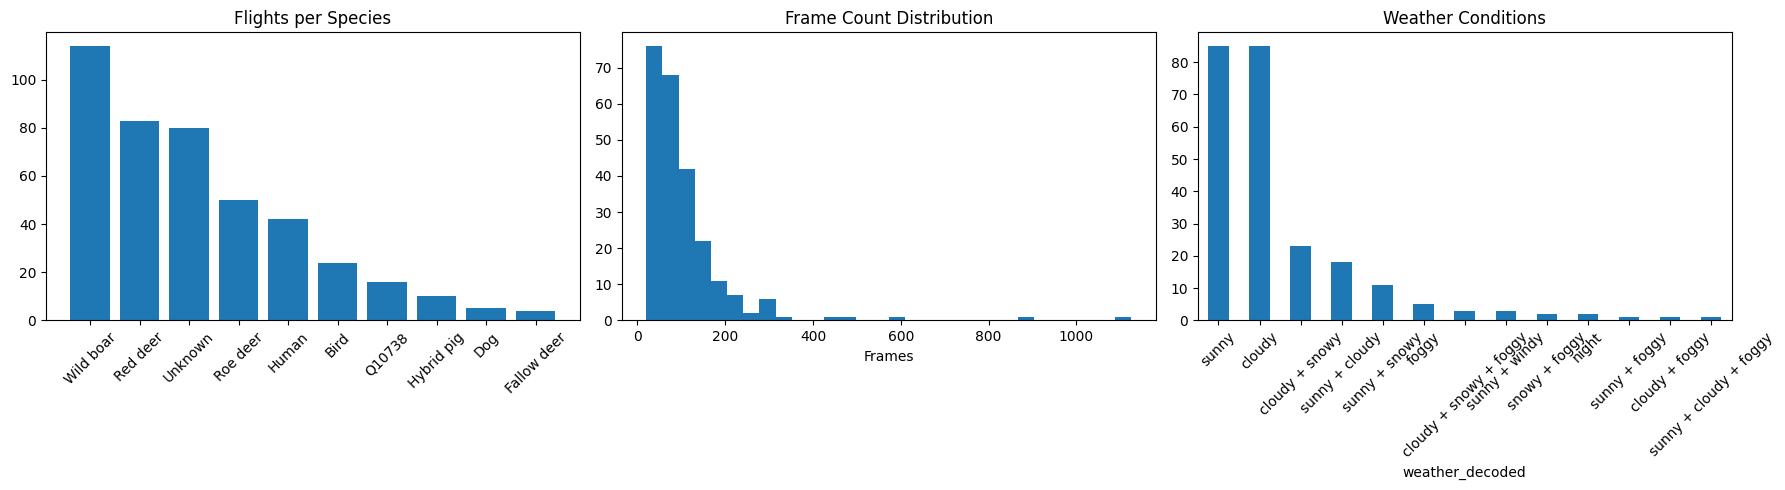

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Species distribution
species_counts = pd.Series([s for sl in df_final["species"] for s in sl]).value_counts()
species_counts.index = [species_map.get(i, i) for i in species_counts.index]
axes[0].bar(species_counts.index, species_counts.values)
axes[0].set_title("Flights per Species")
axes[0].tick_params(axis='x', rotation=45)

# Frame count distribution
axes[1].hist(df_final["frame_count"], bins=30)
axes[1].set_title("Frame Count Distribution")
axes[1].set_xlabel("Frames")

# Weather distribution
weather_flat = df_final["weather_decoded"].apply(lambda x: " + ".join(x))
weather_flat.value_counts().plot(kind="bar", ax=axes[2])
axes[2].set_title("Weather Conditions")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()